In [1]:
import os
import numpy as np
import pandas as pd
import scipy
import scipy.stats as stats
import heartpy
import json

import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DIR_WESAD="./data/WESAD/"
DIR_SAVING_DATA= "./data/Dataset/"

In [3]:
def peak_pos(x: np.array, threshold: float):
    assert len(x.shape) == 1

    # Normalize the signal using Z-score standardization
    x = (x - np.mean(x)) / np.std(x)

    # Smooth the signal using a 5-point moving average convolution
    kernel = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
    smoothed = np.convolve(x, kernel, mode="same")

    baseline = float(np.mean(smoothed))

    peak_index = -1
    peak_indices = []
    peak_value = -100.0

    # Main peak detection loop based on baseline crossings
    for index in range(0, len(smoothed)):
        value = smoothed[index]

        # Update the local peak candidate if the value is above the baseline
        if value > baseline:
            if peak_value == -100.0 or value > peak_value:
                peak_index = index
                peak_value = value

        # Confirm the peak once the signal drops back below the baseline
        if value < baseline and peak_index != -1 and peak_value > threshold:
            peak_indices.append(peak_index)
            peak_index = -1
            peak_value = -100.0

    # Fallback to append the last peak if the signal ends above the baseline
    if peak_index != -1 and peak_value > threshold:
        peak_indices.append(peak_index)

    return np.array(peak_indices)


def TINN(x: np.array):
    # Estimate the probability density function using Gaussian KDE
    kernel = stats.gaussian_kde(x)

    # Compute the x-axis grid spanning from the minimum to maximum interval
    x_axis = np.linspace(np.min(x), np.max(x), len(x))
    density_values = kernel.evaluate(x_axis)

    # Calculate the uniform step size along the x-axis
    step_size = x_axis[1] - x_axis[0]

    # Locate the peak (mode) of the distribution
    max_idx = np.argmax(density_values)
    max_pos = x_axis[max_idx]
    max_value = np.amax(density_values)

    # Split the x-axis grid into two halves around the peak
    n_axis = x_axis[0 : max_idx + 1]
    m_axis = x_axis[max_idx:]

    # Calculate the geometric HRV index
    hrv_index = len(x) / max_value

    err_N = []
    err_M = []

    # 1. Optimize the lower bound N (First half of the distribution)
    for i in range(0, len(n_axis) - 1):
        N = n_axis[i]
        slope = max_value / (max_pos - N)
        target_density = density_values[0 : max_idx + 1]

        # Generate the linear triangular interpolation for the lower segment
        q = np.clip(slope * step_size * np.arange(-i, -i + max_idx + 1), 0, None)

        # Calculate the squared error vector
        diff = target_density - q
        squared_error = np.multiply(diff, diff)

        # Approximate the integral area using the trapezoidal rule
        err1 = np.delete(squared_error, -1)
        err2 = np.delete(squared_error, 0)
        trapezoidal_error = (err1 + err2) / 2
        total_error = np.linalg.norm(trapezoidal_error)

        err_N.append((total_error, N, n_axis, q))

    # 2. Optimize the upper bound M (Second half of the distribution)
    for i in range(1, len(m_axis)):
        M = m_axis[i]
        slope = max_value / (max_pos - M)
        target_density = density_values[max_idx:]

        # Generate the linear triangular interpolation for the upper segment
        q = np.clip(slope * step_size * np.arange(-i, len(target_density) - i), 0, None)

        # Calculate the squared error vector
        diff = target_density - q
        squared_error = np.multiply(diff, diff)

        # Approximate the integral area using the trapezoidal rule
        err1 = np.delete(squared_error, -1)
        err2 = np.delete(squared_error, 0)
        trapezoidal_error = (err1 + err2) / 2
        total_error = np.linalg.norm(trapezoidal_error)

        err_M.append((total_error, M, m_axis, q))

    return (err_N, err_M, x_axis, density_values, hrv_index)



def best_TINN(x: np.array):
    # Extract structural error attributes and geometric data from the TINN function
    err_N, err_M, _, _, hrv_index = TINN(x)

    # Convert the error metrics to a NumPy array to locate the minimum error index
    min_n_idx = np.argmin(np.array(err_N, dtype=object)[:, 0])
    min_m_idx = np.argmin(np.array(err_M, dtype=object)[:, 0])

    # Retrieve the optimal x-axis positions (interbeat interval bounds)
    optimal_N = err_N[min_n_idx][1]
    optimal_M = err_M[min_m_idx][1]

    # Calculate the definitive TINN baseline width score
    tinn_score = optimal_M - optimal_N

    return float(optimal_N), float(optimal_M), float(tinn_score), hrv_index


def compute_nn50(x: np.array):
    # If there are fewer than 2 intervals, NN50 cannot be computed
    if len(x) < 2:
        return 0, 0.0

    # Calculate the absolute differences between successive (neighbor) intervals
    neighbor_diffs = np.abs(np.diff(x))

    # Count how many differences exceed 50 ms (0.05 seconds)
    nn50_count = int(np.sum(neighbor_diffs > 0.05))

    # Calculate the percentage (pNN50) based on the total number of neighbor pairs
    total_pairs = len(neighbor_diffs)
    pnn50_percentage = (
        (nn50_count / total_pairs) if total_pairs > 0 else 0.0
    )

    return nn50_count, pnn50_percentage


def get_freq_features_ecg(x: np.array):
    mean_rri = np.mean(x)

    # Compute the FFT of the de-meaned RRI signal
    fft_values = scipy.fft.fft(x - mean_rri)

    # Generate the frequency axes and isolate the positive half (one-sided spectrum)
    half_len = len(x) // 2
    frequencies = scipy.fft.fftfreq(len(x), mean_rri)[0:half_len]

    # Calculate the Power Spectral Density (PSD) using the original scaling rule
    psd = (2.0 / len(fft_values)) * np.abs(fft_values)[0:half_len]

    # Compute standard frequency-domain statistical metrics
    fmean = np.mean(frequencies)
    fstd = np.std(frequencies)
    sumpsd = np.sum(psd)

    return fmean, fstd, sumpsd

def get_autonomic_features_ecg(x: np.array):
    mean_rri = np.mean(x)

    # Compute the FFT of the de-meaned RRI signal
    fft_values = scipy.fft.fft(x - mean_rri)

    # Generate the frequency axes and isolate the positive half
    half_len = len(x) // 2
    frequencies = scipy.fft.fftfreq(len(x), mean_rri)[0:half_len]

    # Calculate the Power Spectral Density (PSD) matching the existing scaling rule
    psd = (2.0 / len(fft_values)) * np.abs(fft_values)[0:half_len]

    # Define masks for Low-Frequency (LF) and High-Frequency (HF) bands
    lf_mask = (frequencies >= 0.04) & (frequencies <= 0.15)
    hf_mask = (frequencies >= 0.15) & (frequencies <= 0.40)

    # Calculate the power (area under the curve) using the trapezoidal rule
    lf_power = (
        np.trapz(psd[lf_mask], frequencies[lf_mask]) if np.any(lf_mask) else 0.0
    )
    hf_power = (
        np.trapz(psd[hf_mask], frequencies[hf_mask]) if np.any(hf_mask) else 0.0
    )

    # Calculate the LF/HF ratio as the index of sympathetic/parasympathetic balance
    lf_hf_ratio = (lf_power / hf_power) if hf_power > 0.0 else 0.0

    return hf_power, lf_hf_ratio



def compute_sd2(x: np.array):
    if len(x) < 2:
        return 0.0

    # Separate the intervals into successive pairs (x_i and x_{i+1})
    rri_current = x[:-1]
    rri_next = x[1:]

    # SD2 is proportional to the standard deviation of the sum of successive intervals
    # Equation: SD2^2 = 2 * Var( (x_i + x_{i+1}) / sqrt(2) ) = Var(x_i + x_{i+1})
    # Therefore: SD2 = std(x_i + x_{i+1}) / sqrt(2)
    rri_sum = rri_current + rri_next

    # Using ddof=1 for sample standard deviation to ensure scientific accuracy
    sd2 = np.std(rri_sum, ddof=1) / np.sqrt(2)

    return float(sd2)

import numpy as np



def get_data_ecg(x: np.array):
    # Extract peak indices using HeartPy at the WESAD standard 700Hz sampling rate
    working_data, measures = heartpy.process(x, 700)
    peak_list = working_data["peaklist"]

    # If not enough peaks are detected to compute intervals, return a safe zero-vector
    if len(peak_list) < 2:
        return np.zeros(14)

    # 1. Calculate continuous instantaneous frequencies (cycles per second)
    # Replaced loop with optimized NumPy vectorized operations
    peak_diffs = np.diff(peak_list)
    periods = peak_diffs / 700.0
    frequency = 1.0 / periods

    mean_freq = np.mean(frequency)
    std_freq = np.std(frequency)

    # 2. Extract Heart Rate Variability (HRV) interval array (RRI in seconds)
    hrv_intervals = peak_diffs / 700.0

    # 3. Compute structural and geometric features (TINN metrics)
    _, _, T_score, hrv_index = best_TINN(hrv_intervals)

    # 4. Compute updated time-domain features (Optimized neighbor-only NN50)
    num50, p50 = compute_nn50(hrv_intervals)

    mean_hrv = np.mean(hrv_intervals)
    std_hrv = np.std(hrv_intervals)
    rmssd = np.sqrt(np.mean(np.diff(hrv_intervals)**2))

    # 5. Compute base frequency features via FFT
    fmean, fstd, sum_psd = get_freq_features_ecg(hrv_intervals)

    # 6. Compute new additions: Autonomic balance and geometric metrics
    hf_power, lf_hf_ratio = get_autonomic_features_ecg(hrv_intervals)
    sd2_score = compute_sd2(hrv_intervals)

    # Return the clean 14-feature vector mapped perfectly to your new architecture
    return np.array(
        [
            mean_freq,
            std_freq,
            T_score,
            hrv_index,
            num50,
            p50,
            mean_hrv,
            std_hrv,
            rmssd,
            fmean,
            fstd,
            sum_psd,
            hf_power,
            lf_hf_ratio,
            sd2_score,
        ]
    )


def slice_per_label(label_sequence: np.array, sampling_rate: int, time_window: int, step: int):
    window_points = time_window * sampling_rate
    valid_segments = []

    # Slide across the sequence using the designated step size
    for i in range(0, len(label_sequence) - window_points, sampling_rate * step):
        window_data = label_sequence[i : i + window_points]
        
        # Calculate the total sum of the window to verify constancy
        window_sum = np.sum(window_data)
        initial_label = label_sequence[i]

        # WESAD valid target emotional states
        if initial_label in [1, 2, 3, 4]:
            # If all values match initial_label, their sum must equal initial_label * window_points
            is_constant = (initial_label * window_points) == window_sum
            
            if is_constant:
                valid_segments.append((i, initial_label))

    return valid_segments

import numpy as np
import pandas as pd
from IPython.display import clear_output


def get_ecg_features_from_file(file_path: str):
    subject_ids = []  # Matches original 'id' tracking array
    labels = []
    features_list = []
    
    sampling_rate = 700
    progress_counter = 0
    discarded_infinite = 0
    discarded_errors = 0
    window_points = 60 * sampling_rate

    # Load the WESAD subject pickle dataframe
    df = pd.read_pickle(file_path)
    label_sequence = df["label"]
    print("File opened successfully.")

    # Locate the start and end boundary indices for the neutral baseline phase (label 1)
    neutral_indices = np.where(label_sequence == 1)[0]
    
    # Generate all uniform-label time-window starting coordinates
    valid_segments = slice_per_label(label_sequence, sampling_rate=700, time_window=60, step=5)
    print("Window indices sliced.")

    # Extract and calculate the raw reference baseline data matrix
    # Keeping your original indexing math completely intact
    baseline_ecg = df["signal"]["chest"]["ECG"][
        neutral_indices[0] : neutral_indices[0] + 60 * 700
    ][:, 0]
    baseline_features = get_data_ecg(baseline_ecg)

    # Process each valid window segment sequentially
    for segment in valid_segments:
        progress_counter += 1
        if progress_counter % 100 == 0:
            clear_output(wait=True)
            print(f"Processing file: {file_path}")
            print(f"Progress: {progress_counter / len(valid_segments):.2%}")

        start_idx = segment[0]
        target_label = segment[1]

        try:
            # Slicing matching your exact frequency scale factor rules
            window_ecg = np.array(
                df["signal"]["chest"]["ECG"][
                    (start_idx * sampling_rate) // 700 : (window_points + start_idx) * sampling_rate // 700
                ][:, 0]
            )

            # Extract window features and apply baseline normalization (element-wise division)
            normalized_features = np.divide(get_data_ecg(window_ecg), baseline_features)

            # Check for invalid division elements (Inf / NaN values)
            if not (np.isinf(normalized_features).any() or np.isnan(normalized_features).any()):
                features_list.append(normalized_features.tolist())
                labels.append(int(target_label))
            else:
                discarded_infinite += 1

        except KeyboardInterrupt:
            print("Execution interrupted by user.")
            raise  # Replaced 1/0 with standard clean Python interruption propagation
        except Exception:
            discarded_errors += 1

    print(f"Rejected due to infinite or NaN values: {discarded_infinite}")
    print(f"Rejected due to processing routine errors: {discarded_errors}")

    return features_list, subject_ids, labels, discarded_infinite, discarded_errors, baseline_ecg

In [4]:
# Generate the subject list by filtering out hidden system files and documentation files
subject_directories = [
    directory_name
    for directory_name in os.listdir(DIR_WESAD)
    if not directory_name.startswith(".") and directory_name != "wesad_readme.pdf"
]

processed_count = 0
total_subjects = len(subject_directories)

# Iterate through each subject folder to extract, normalize, and serialize data
for subject_name in subject_directories:
    processed_count += 1

    # Build the strict absolute path pointing to the subject pickle file
    pickle_file_path = f"{DIR_WESAD}{subject_name}/{subject_name}.pkl"

    print(f"Starting extraction for subject: {subject_name}")
    print(f"Subject processing progress: {processed_count} / {total_subjects}")

    # Run the newly refactored English 14-feature extraction pipeline
    (
        features_list,
        subject_ids,
        labels,
        discarded_infinite,
        discarded_errors,
        baseline_ecg,
    ) = get_ecg_features_from_file(pickle_file_path)

    # Structure the sanitized array logs directly into the subject data payload
    subject_data_payload = {
        "id": subject_ids,
        "label": labels,
        "features": features_list,
    }

    # Construct the output file target path
    output_json_path = f"{DIR_SAVING_DATA}WESADECG_{subject_name}.json"

    # Serialize and save the subject metrics payload into a clean JSON structure
    with open(output_json_path, "w") as json_file:
        json.dump(subject_data_payload, json_file)

    print(f"Successfully saved features to: {output_json_path}\n")

Processing file: ./data/WESAD/S15/S15.pkl
Progress: 91.58%
Rejected due to infinite or NaN values: 0
Rejected due to processing routine errors: 0
Successfully saved features to: ./data/Dataset/WESADECG_S15.json



=== WESAD ECG Feature Dimensions Summary ===
Total extracted windows matrix size: (8091, 17)

=== Descriptive Statistics (All 15 Features) ===


,count,mean,std,min,25%,50%,75%,max
Mean Frequency,8091.0,1.033928,0.441929,0.041649,0.886086,1.003463,1.117827,10.739811
Std Frequency,8091.0,3.976503,34.674497,0.000743,0.644133,0.889341,1.181939,804.370611
TINN T-Score,8091.0,0.884214,0.341056,0.077031,0.648608,0.866967,1.089855,2.441386
HRV Index,8091.0,0.932513,0.373384,0.104385,0.672868,0.883002,1.145080,2.854818
NN50 Count,8091.0,1.196089,1.561339,0.000000,0.463415,0.764706,1.120000,14.500000
pNN50 Percentage,8091.0,1.255549,1.775198,0.000000,0.434249,0.789953,1.228387,17.767606
Mean HRV (RRI),8091.0,0.980700,0.178545,0.449012,0.896567,0.989588,1.074756,1.601673
Std HRV (SDNN),8091.0,0.919509,0.413705,0.081810,0.655709,0.861978,1.110352,4.883082
RMSSD,8091.0,0.974117,0.948735,0.039303,0.534659,0.793046,1.121710,16.275805
FFT Mean Frequency,8091.0,1.061618,0.245267,0.606009,0.926102,1.006706,1.120979,2.252771



=== Target Content Class Distribution ===
Condition
Neutral       3342
Meditation    2001
Stress        1814
Amusement      934
Name: count, dtype: int64

Generating ALL 15 feature distribution visualizer matrices...


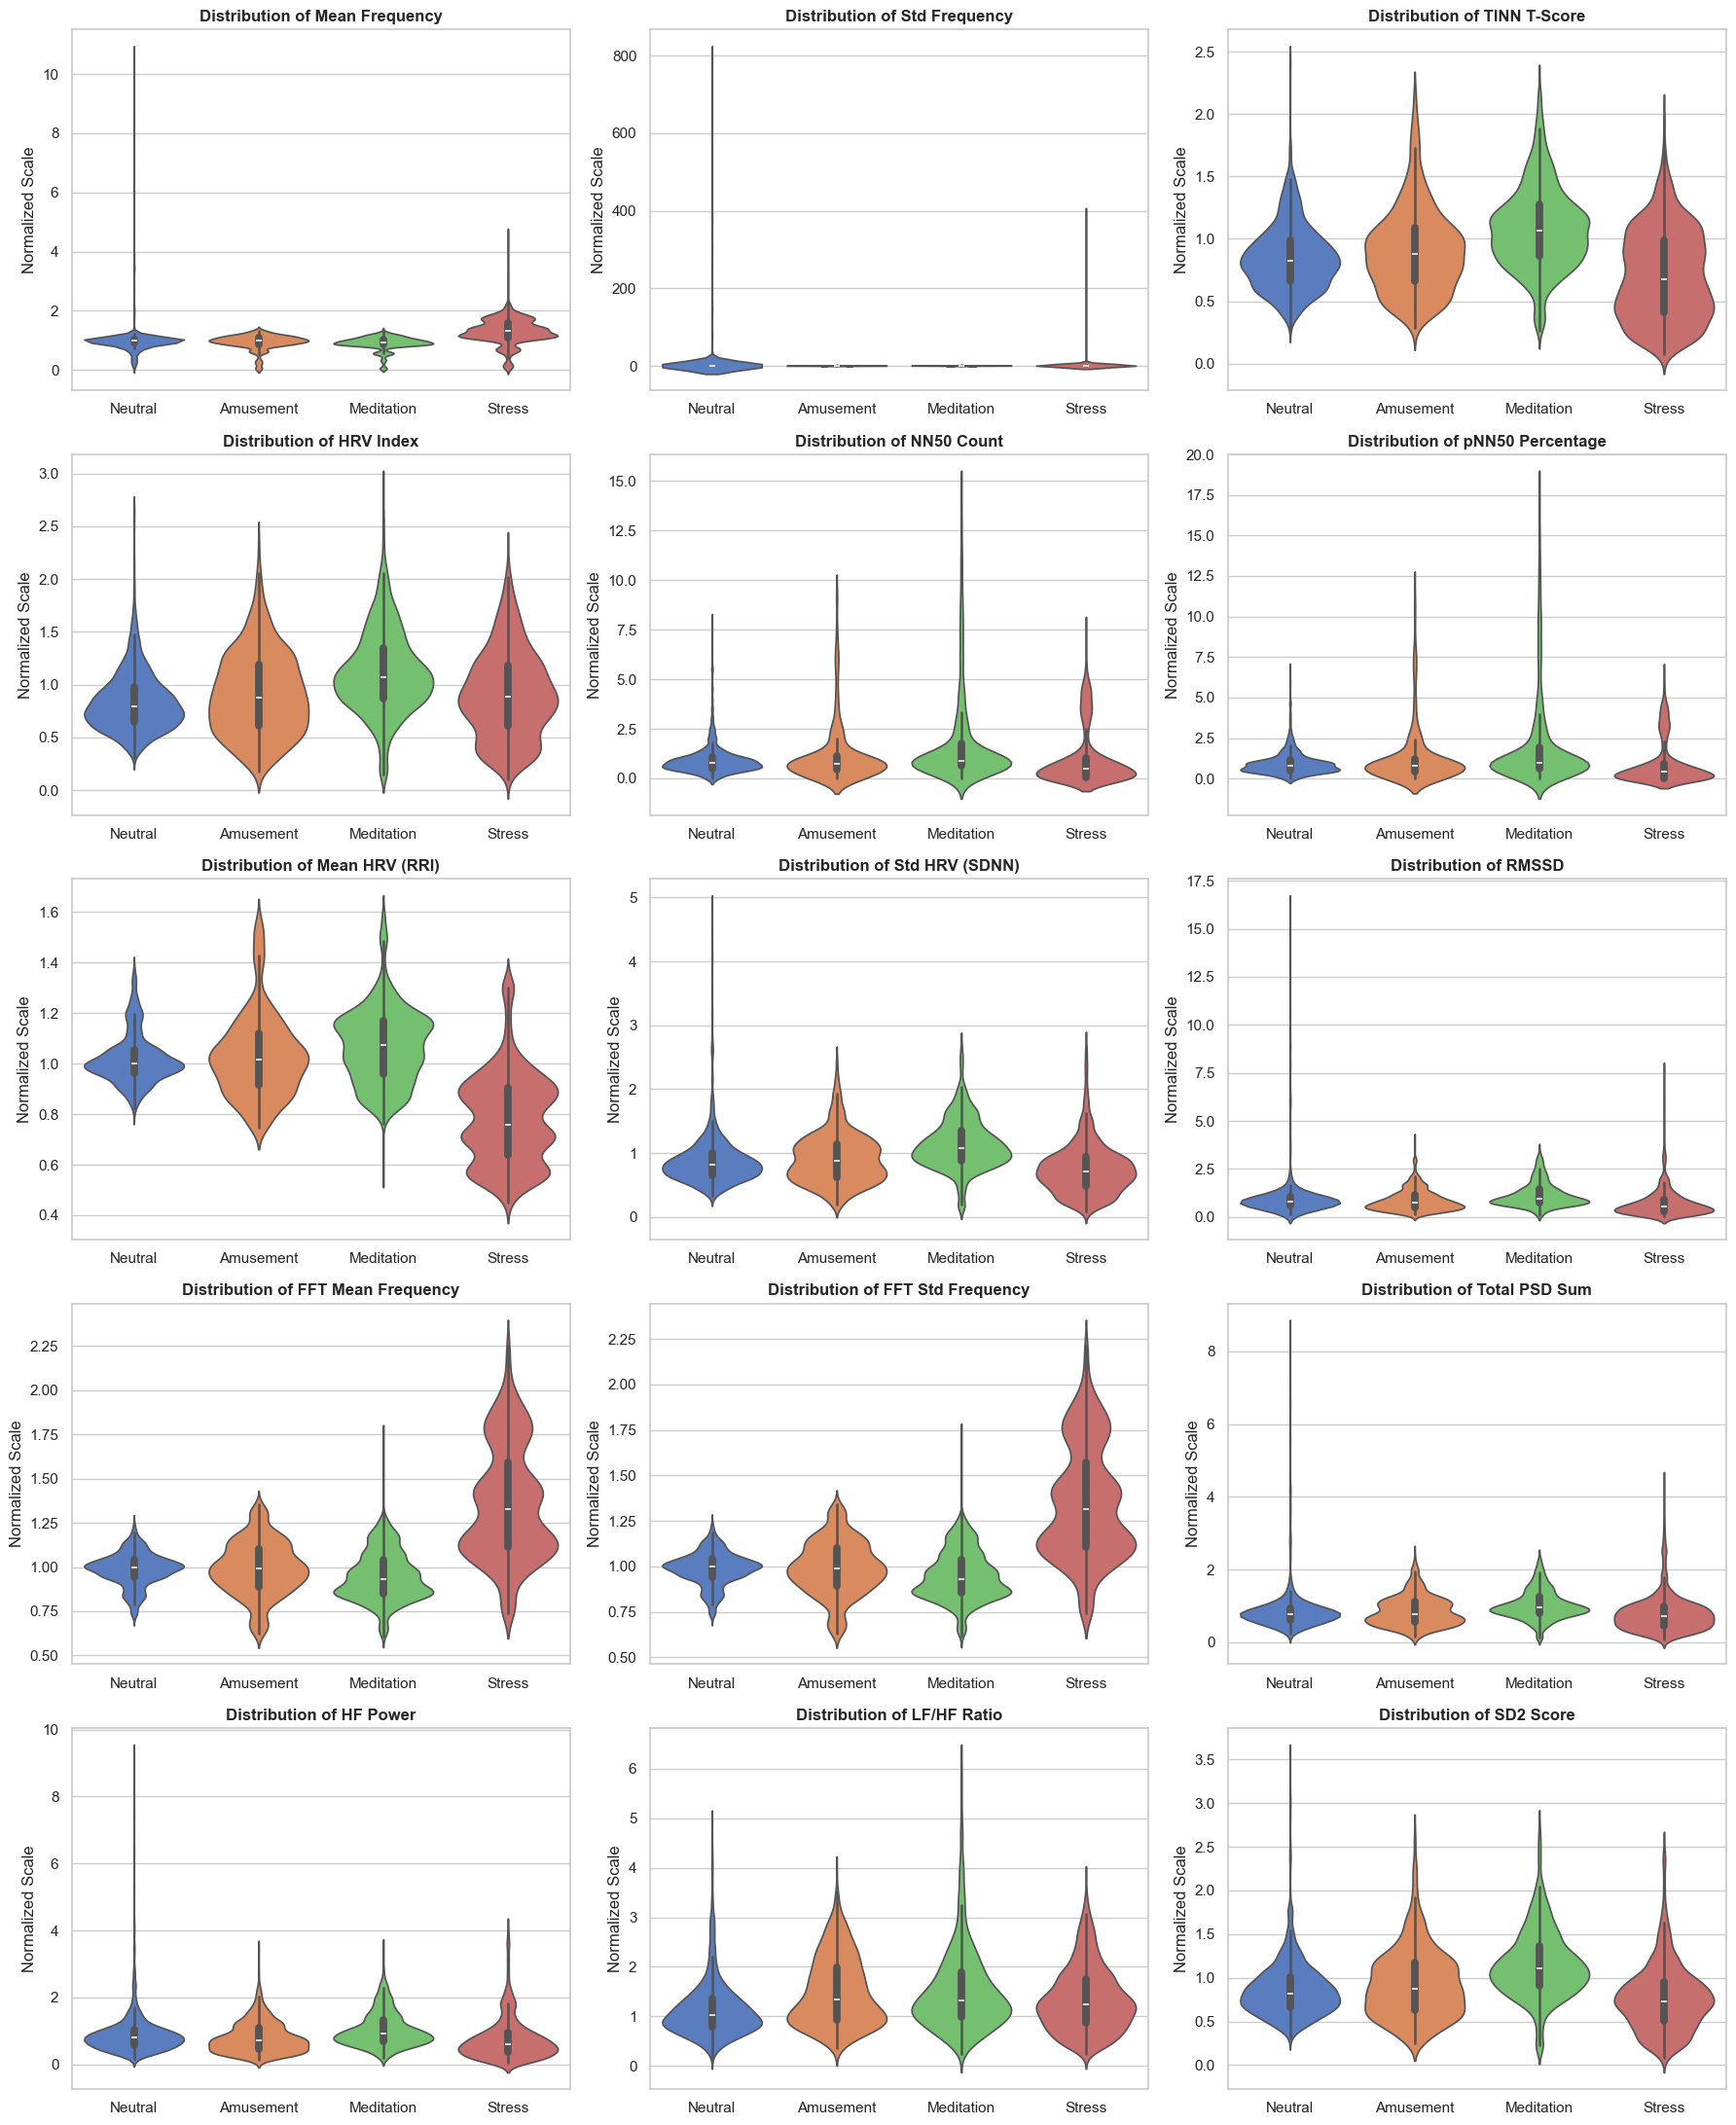

In [5]:
# 1. Load and aggregate all subject JSON metrics into a single DataFrame
all_features = []
all_labels = []

json_files = [
    f for f in os.listdir(DIR_SAVING_DATA) if f.startswith("WESADECG_")
]

for file_name in sorted(json_files):
    with open(os.path.join(DIR_SAVING_DATA, file_name), "r") as f:
        data = json.load(f)
        if data["features"]:
            all_features.extend(data["features"])
            all_labels.extend(data["label"])

# EXACT 15 FEATURE NAMES (Must match the exact return order of get_data_ecg)
feature_names = [
    "Mean Frequency",
    "Std Frequency",
    "TINN T-Score",
    "HRV Index",
    "NN50 Count",
    "pNN50 Percentage",
    "Mean HRV (RRI)",
    "Std HRV (SDNN)",
    "RMSSD",
    "FFT Mean Frequency",
    "FFT Std Frequency",
    "Total PSD Sum",
    "HF Power",
    "LF/HF Ratio",
    "SD2 Score",  # Row 15
]

# Construct primary features dataframe safely
df_features = pd.DataFrame(all_features, columns=feature_names)

# Append meta tracks WITHOUT overwriting any feature columns
df_analysis = df_features.copy()
df_analysis["Label_ID"] = all_labels

# WESAD standard structural label classification definitions
label_mapping = {1: "Neutral", 2: "Stress", 3: "Amusement", 4: "Meditation"}
df_analysis["Condition"] = df_analysis["Label_ID"].map(label_mapping)

# Drop any unmapped target labels safely if they exist
df_analysis = df_analysis.dropna(subset=["Condition"])

# 2. Statistical Analysis Report (Will now include SD2 Score explicitly)
print("=== WESAD ECG Feature Dimensions Summary ===")
print(f"Total extracted windows matrix size: {df_analysis.shape}")

print("\n=== Descriptive Statistics (All 15 Features) ===")
# Explicitly display only the 15 features in the table to avoid confusion
display(df_analysis[feature_names].describe().T)

print("\n=== Target Content Class Distribution ===")
print(df_analysis["Condition"].value_counts())

# 3. Data Visualization Matrix (Violin Plots for ALL 15 features)
sns.set_theme(style="whitegrid")

# 5 rows x 3 columns = exactly 15 subplots
fig, axes = plt.subplots(5, 3, figsize=(18, 22))
axes = axes.flatten()

print("\nGenerating ALL 15 feature distribution visualizer matrices...")
for idx, feature in enumerate(feature_names):
    sns.violinplot(
        data=df_analysis,
        x="Condition",
        y=feature,
        ax=axes[idx],
        palette="muted",
        hue="Condition",
        legend=False,
    )
    axes[idx].set_title(f"Distribution of {feature}", fontsize=12, weight="bold")
    axes[idx].set_xlabel("")
    axes[idx].set_ylabel("Normalized Scale")

plt.tight_layout()
plt.show()

In [6]:
import os
import shutil
# Isolating S17 data for evaluation to prevent data leakage.

# 1. Define paths
DIR_DATA = "./data/Dataset/"
DIR_DATA_TEST = "./data/Testing/"
SUBJECT_USED_FOR_TESTING = "S17"

test_file = f"WESADECG_{SUBJECT_USED_FOR_TESTING}.json"
src = os.path.join(DIR_DATA, test_file)
dst = os.path.join(DIR_DATA_TEST, test_file)

# 2. Create target directory if it doesn't exist
os.makedirs(DIR_DATA_TEST, exist_ok=True)

# 3. Move the file
if os.path.exists(src):
    shutil.move(src, dst)
    print(f"Moved {test_file} to {DIR_DATA_TEST}")
elif os.path.exists(dst):
    print(f"{test_file} is already in {DIR_DATA_TEST}")
else:
    print(f"Error: {test_file} not found in {DIR_DATA}")

Moved WESADECG_S17.json to ./data/Testing/
